# Question 3: Top Reviewers

The goal of this notebook is to analyze:
- Favorite pages
- Faverotie categories
- Degree correlation plots
- Total nummber of revisions
- Daily number of revisions
- % of total Wikipedia contribution
- % of contirbution in the categories they are involved


In [60]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

graph = pl.read_ipc("reviewers_graph.feather")
revisions = pl.read_parquet("../revisions_no_bots.parquet")
categories = pl.read_parquet("../goodwiki_with_categories.parquet")


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [61]:
categories = categories.select("pageid", "categories_depth_5").explode("categories_depth_5").rename({"categories_depth_5": "category"})
categories.head()

pageid,category
i64,str
57185536,"""American_women_writers_by_cent…"
57185536,"""Births_by_year"""
57185536,"""Republicans_(United_States)_by…"
57185536,"""19th-century_American_people_b…"
57185536,"""20th-century_American_people_b…"


## Filter main reviewers

In [62]:
revisions.head()

revid,parentid,minor,user,userid,timestamp,size,slots,tags,pageid,title
i64,i64,bool,str,f64,str,i64,struct[1],list[str],i64,str
1163683705,1073278143,false,"""Smasongarrison""",1.6185737e7,"""2023-07-06T02:12:52Z""",14787,"{{""wikitext"",14787}}","[""AWB""]",57185536,"""Georgia Hopley"""
1170257280,1169998062,true,"""Smasongarrison""",1.6185737e7,"""2023-08-14T00:52:02Z""",39439,"{{""wikitext"",39439}}",[],15394015,"""Willis Ward"""
1162127828,1160202917,true,"""Minorax""",3.6529075e7,"""2023-06-27T04:21:11Z""",39390,"{{""wikitext"",39390}}","[""wikieditor""]",15394015,"""Willis Ward"""
1160202917,1160202005,false,"""SheridanFord""",4.263828e6,"""2023-06-15T01:20:50Z""",39421,"{{""wikitext"",39421}}","[""visualeditor""]",15394015,"""Willis Ward"""
1160202005,1152748211,false,"""SheridanFord""",4.263828e6,"""2023-06-15T01:11:16Z""",38839,"{{""wikitext"",38839}}","[""visualeditor""]",15394015,"""Willis Ward"""


In [63]:
top_reviewers = graph.group_by("from").agg(pl.col("from").count().alias("num_links")).sort("num_links", descending=True)[:5]
list_ids = top_reviewers["from"].to_list()
filtered_revisions = revisions.select("user", "userid", "title", "pageid").filter(pl.col("userid").is_in(list_ids))

## Favorite Pages

In [64]:
_fav = (
    revisions
    .filter(pl.col("userid").is_in(list_ids))
    .group_by("title", "user")
    .agg(pl.col("revid").count().alias("count"))
    .sort("count", descending=True)
)
_fav[9:]

title,user,count
str,str,u32
"""Hyderabad""","""Arjayay""",9
"""Kyle Broflovski""","""Materialscientist""",8
"""Philosophy""","""HeyElliott""",8
"""Chapters of 2 Maccabees""","""Rodw""",8
"""Washington, D.C.""","""HeyElliott""",8
…,…,…
"""Mandera Prison""","""Arjayay""",1
"""Welding""","""Materialscientist""",1
"""Teresa Sampsonia""","""Rodw""",1


## Favorite Categories

In [70]:
_cat = (
    filtered_revisions
    .join(categories, left_on="pageid", right_on="pageid", how="left")
    .group_by("category", "user")
    .agg(pl.col("category").count().alias("count"))
    .sort("count", descending=True)
)
_cat.group_by("user").head(1)

user,category,count
str,str,u32
"""Materialscientist""","""Births_by_year""",697
"""Discospinster""","""Births_by_year""",316
"""Rodw""","""Births_by_year""",249
"""Arjayay""","""Births_by_year""",243
"""HeyElliott""","""Births_by_year""",399


## Number of revisions by top reviewers

In [34]:
_num_reviews = (
    revisions
    .filter(pl.col("userid").is_in(list_ids))
    .select("userid", "revid", "user")
    .group_by("userid", "user")
    .agg(pl.col("revid").count().alias("num_reviews"))
    .sort("num_reviews", descending=True)
)
_num_reviews

userid,user,num_reviews
f64,str,u32
7.85203e6,"""Materialscientist""",2223
4.4120587e7,"""HeyElliott""",1969
5.718152e6,"""Arjayay""",1112
82432.0,"""Discospinster""",1088
125972.0,"""Rodw""",913


# Degree correlation plots

In [20]:
_temp = top_reviewers.join(filtered_revisions.select("userid", "user").unique(), right_on="userid", left_on="from", how="inner").sort("num_links", descending=True)[:5]
_temp.head()

from,num_links,user
f64,u32,str
7.85203e6,14381,"""Materialscientist"""
4.4120587e7,13425,"""HeyElliott"""
82432.0,8986,"""Discospinster"""
5.718152e6,7923,"""Arjayay"""
125972.0,7606,"""Rodw"""


/tmp/ipykernel_4938/2689339104.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


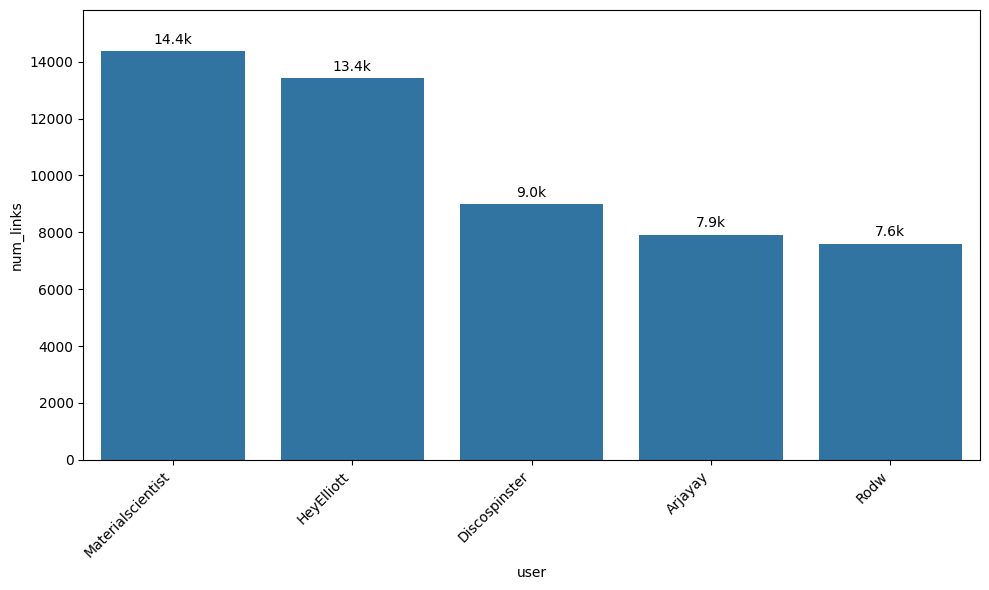

In [21]:
plt.figure(figsize=(10, 6)) # Optional: adjusts size for better visibility
ax = sns.barplot(data=_temp, x="user", y="num_links")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# --- Step B: Define Formatting Function ---
def format_k(value):
    """Converts 7200 to 7.2k, leaves 450 as 450"""
    if value >= 1000:
        return f'{value/1000:.1f}k'
    return f'{int(value)}'


for container in ax.containers:
    labels = [format_k(bar.get_height()) for bar in container]
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.margins(y=0.1) 

plt.tight_layout()
plt.show()